# Exploratory Data Analysis (EDA)
## Modelling Singapore Birth and Fertility Rates, 1960–2025

### Goals
- Understand long-term trends in births and fertility.
- Examine crude birth rate.
- Analyse age-specific fertility.
- Compare Chinese, Malay and Indian fertility.
- Compare total, resident and citizen live births.
- Identify unusual changes and important periods.
- Produce figures and tables for the capstone report.

In [25]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

FIG_DIR = "figures"
TABLE_DIR = "tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

## 1. Load the cleaned dataset

In [26]:
DATA_PATH = "outputs/annual_birth_fertility_cleaned.csv"

if not os.path.exists(DATA_PATH):
    alternatives = [
        "/mnt/data/annual_birth_fertility_cleaned.csv",
        "/content/outputs/annual_birth_fertility_cleaned.csv"
    ]
    for p in alternatives:
        if os.path.exists(p):
            DATA_PATH = p
            break

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "Could not find annual_birth_fertility_cleaned.csv. "
        "Run Notebook 01 first or change DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype(int)
df = df.sort_values("Year").reset_index(drop=True)

print("Shape:", df.shape)
print("Years:", df["Year"].min(), "to", df["Year"].max())
display(df.head())
display(df.tail())

Shape: (66, 18)
Years: 1960 to 2025


,Year,Total_Fertility_Rate_TFR,15_19_Years,20_24_Years,25_29_Years,30_34_Years,35_39_Years,40_44_Years,45_49_Years,Chinese,Malays,Indians,Gross_Reproduction_Rate,Net_Reproduction_Rate,Crude_Birth_Rate,Total_Live_Births,Resident_Live_Births,Citizen_Live_Births
0,1960,5.7600,69.6000,250.5000,323.9000,259.7000,176.7000,70.7000,NaN,5.6200,6.4200,7.3700,2.7800,2.5400,37.5000,"61,775.0000",NaN,NaN
1,1961,5.4100,63.4000,241.1000,304.9000,238.4000,168.9000,64.8000,NaN,5.2000,6.4200,6.9600,2.6300,2.4100,35.2000,"59,930.0000",NaN,NaN
2,1962,5.2100,52.0000,245.5000,291.7000,231.5000,156.2000,65.1000,NaN,4.9200,6.6300,6.9600,2.5300,2.3100,33.7000,"58,977.0000",NaN,NaN
3,1963,5.1600,45.7000,249.0000,287.2000,228.7000,156.1000,64.9000,NaN,4.8300,6.7500,6.9000,2.5100,2.3000,33.2000,"59,530.0000",NaN,NaN
4,1964,4.9700,38.3000,240.0000,277.6000,226.7000,147.7000,62.8000,NaN,4.6000,6.7800,7.0600,2.4200,2.2200,31.6000,"58,217.0000",NaN,NaN


,Year,Total_Fertility_Rate_TFR,15_19_Years,20_24_Years,25_29_Years,30_34_Years,35_39_Years,40_44_Years,45_49_Years,Chinese,Malays,Indians,Gross_Reproduction_Rate,Net_Reproduction_Rate,Crude_Birth_Rate,Total_Live_Births,Resident_Live_Births,Citizen_Live_Births
61,2021,1.1200,2.2000,11.7000,53.4000,92.9000,53.6000,10.2000,0.3000,0.9600,1.8200,1.0500,0.5400,0.5400,8.6000,"38,672.0000","34,183.0000","31,713.0000"
62,2022,1.0400,2.1000,11.2000,48.8000,86.7000,49.4000,9.8000,0.4000,0.8700,1.8300,1.0100,0.5000,0.5000,7.9000,"35,605.0000","32,290.0000","30,429.0000"
63,2023,0.9700,2.2000,10.6000,43.7000,78.7000,47.9000,9.6000,0.6000,0.8100,1.6500,0.9500,0.4600,0.4600,7.4000,"33,541.0000","30,518.0000","28,877.0000"
64,2024,0.9700,2.3000,9.8000,42.6000,79.3000,50.0000,10.2000,0.7000,0.8300,1.5800,0.9100,0.4700,0.4700,7.4000,"33,703.0000","30,808.0000","29,237.0000"
65,2025,0.8700,1.3000,8.7000,38.1000,69.7000,46.0000,9.5000,0.5000,0.7000,1.5300,0.9200,0.4200,0.4200,6.5000,"29,864.0000","27,393.0000","26,071.0000"


# Part A — Dataset overview

In [27]:
print("Variables:")
for c in df.columns:
    print(" -", c)

missing = pd.DataFrame({
    "Variable": df.columns,
    "Missing_Count": [df[c].isna().sum() for c in df.columns],
    "Available_Count": [df[c].notna().sum() for c in df.columns],
    "First_Available_Year": [
        df.loc[df[c].notna(), "Year"].min() if df[c].notna().any() else np.nan
        for c in df.columns
    ],
    "Last_Available_Year": [
        df.loc[df[c].notna(), "Year"].max() if df[c].notna().any() else np.nan
        for c in df.columns
    ]
})
display(missing)
missing.to_csv(os.path.join(TABLE_DIR, "eda_missing_value_summary.csv"), index=False)

Variables:
 - Year
 - Total_Fertility_Rate_TFR
 - 15_19_Years
 - 20_24_Years
 - 25_29_Years
 - 30_34_Years
 - 35_39_Years
 - 40_44_Years
 - 45_49_Years
 - Chinese
 - Malays
 - Indians
 - Gross_Reproduction_Rate
 - Net_Reproduction_Rate
 - Crude_Birth_Rate
 - Total_Live_Births
 - Resident_Live_Births
 - Citizen_Live_Births


,Variable,Missing_Count,Available_Count,First_Available_Year,Last_Available_Year
0,Year,0,66,1960,2025
1,Total_Fertility_Rate_TFR,0,66,1960,2025
2,15_19_Years,0,66,1960,2025
3,20_24_Years,0,66,1960,2025
4,25_29_Years,0,66,1960,2025
5,30_34_Years,0,66,1960,2025
6,35_39_Years,0,66,1960,2025
7,40_44_Years,0,66,1960,2025
8,45_49_Years,20,46,1980,2025
9,Chinese,0,66,1960,2025


# Part B — Primary targets: Total Live-Births and Total Fertility Rate

In [28]:
targets = ["Total_Live_Births", "Total_Fertility_Rate_TFR"]

summary = df[targets].describe().T
display(summary)
summary.to_csv(os.path.join(TABLE_DIR, "eda_core_descriptive_statistics.csv"))

key_years = [1960, 1970, 1980, 1990, 2000, 2010, 2012, 2013, 2020, 2025]
key = df.loc[
    df["Year"].isin(key_years),
    ["Year", "Total_Live_Births", "Total_Fertility_Rate_TFR",
     "Crude_Birth_Rate"]
].copy()
display(key)
key.to_csv(os.path.join(TABLE_DIR, "eda_key_year_comparison.csv"), index=False)

,count,mean,std,min,25%,50%,75%,max
Total_Live_Births,66.0000,"44,140.0000","6,816.8061","29,864.0000","39,510.0000","42,367.0000","48,500.0000","61,775.0000"
Total_Fertility_Rate_TFR,66.0000,2.0450,1.2339,0.8700,1.2600,1.6200,2.0425,5.7600


,Year,Total_Live_Births,Total_Fertility_Rate_TFR,Crude_Birth_Rate
0,1960,"61,775.0000",5.7600,37.5000
10,1970,"45,934.0000",3.0700,22.1000
20,1980,"41,217.0000",1.8200,17.6000
30,1990,"51,142.0000",1.8300,18.2000
40,2000,"46,997.0000",1.6000,13.7000
50,2010,"37,967.0000",1.1500,9.3000
52,2012,"42,663.0000",1.2900,10.1000
53,2013,"39,720.0000",1.1900,9.3000
60,2020,"38,590.0000",1.1000,8.5000
65,2025,"29,864.0000",0.8700,6.5000


## Figure 1 — Total Live-Births, 1960–2025

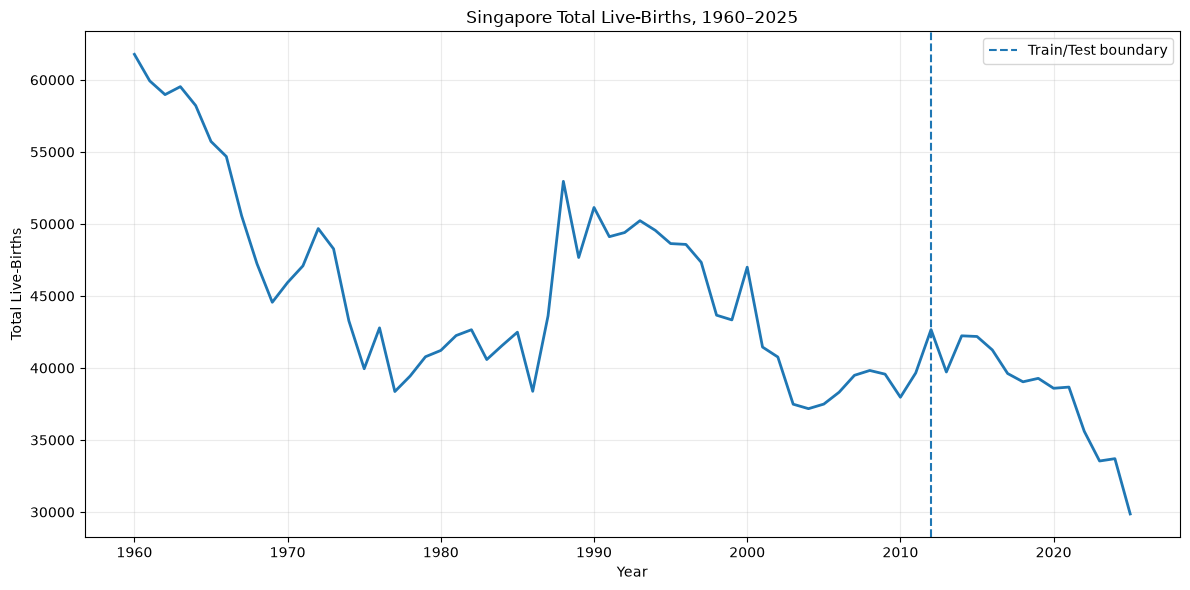

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["Year"], df["Total_Live_Births"], linewidth=2)
ax.axvline(2012, linestyle="--", linewidth=1.5,
           label="Train/Test boundary")
ax.set_title("Singapore Total Live-Births, 1960–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Total Live-Births")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Figure_01_Total_Live_Births_1960_2025.png"),
            dpi=300, bbox_inches="tight")
plt.show()

## Figure 2 — Total Fertility Rate, 1960–2025

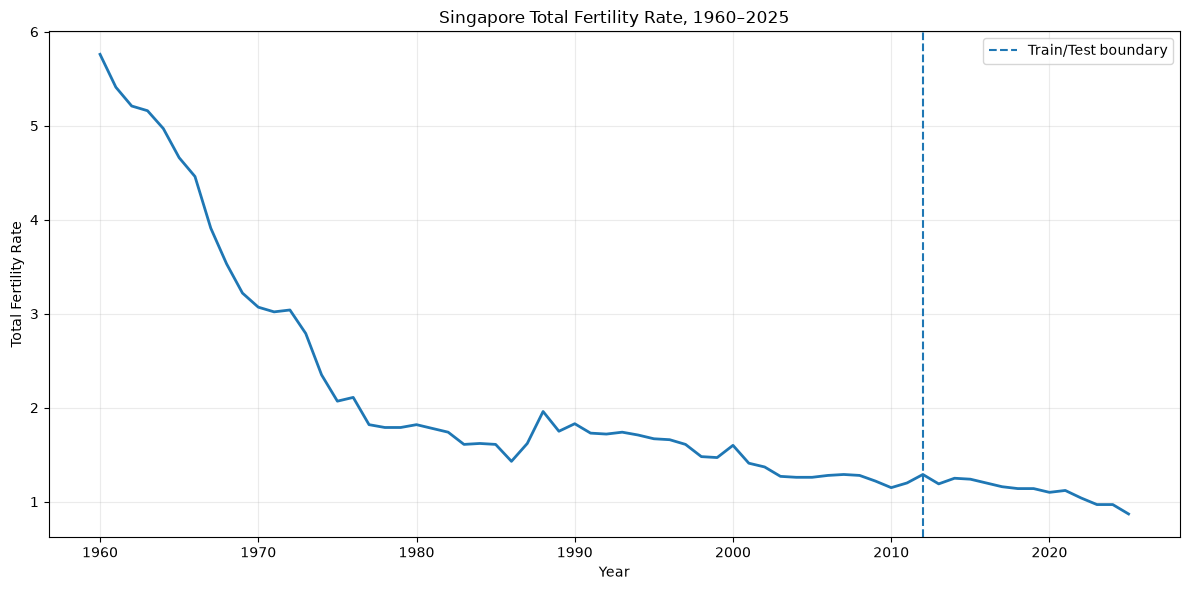

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["Year"], df["Total_Fertility_Rate_TFR"], linewidth=2)
ax.axvline(2012, linestyle="--", linewidth=1.5,
           label="Train/Test boundary")
ax.set_title("Singapore Total Fertility Rate, 1960–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Total Fertility Rate")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Figure_02_TFR_1960_2025.png"),
            dpi=300, bbox_inches="tight")
plt.show()

## Long-term change

In [31]:
first = df.iloc[0]
last = df.iloc[-1]

birth_change = last["Total_Live_Births"] - first["Total_Live_Births"]
birth_pct = birth_change / first["Total_Live_Births"] * 100

tfr_change = last["Total_Fertility_Rate_TFR"] - first["Total_Fertility_Rate_TFR"]
tfr_pct = tfr_change / first["Total_Fertility_Rate_TFR"] * 100

print(f"Total live-birth change, 1960 to 2025: {birth_change:,.0f}")
print(f"Total live-birth percentage change: {birth_pct:.2f}%")
print()
print(f"TFR change, 1960 to 2025: {tfr_change:.2f}")
print(f"TFR percentage change: {tfr_pct:.2f}%")

df["Births_YoY_Pct"] = df["Total_Live_Births"].pct_change() * 100
df["TFR_YoY_Pct"] = df["Total_Fertility_Rate_TFR"].pct_change() * 100

print("\nLargest birth declines:")
display(df.dropna(subset=["Births_YoY_Pct"])
          .nsmallest(10, "Births_YoY_Pct")
          [["Year", "Total_Live_Births", "Births_YoY_Pct"]])

print("Largest birth increases:")
display(df.dropna(subset=["Births_YoY_Pct"])
          .nlargest(10, "Births_YoY_Pct")
          [["Year", "Total_Live_Births", "Births_YoY_Pct"]])

Total live-birth change, 1960 to 2025: -31,911
Total live-birth percentage change: -51.66%

TFR change, 1960 to 2025: -4.89
TFR percentage change: -84.90%

Largest birth declines:


,Year,Total_Live_Births,Births_YoY_Pct
41,2001,"41,451.0000",-11.8008
65,2025,"29,864.0000",-11.3907
14,1974,"43,268.0000",-10.3607
17,1977,"38,364.0000",-10.3289
29,1989,"47,669.0000",-9.9855
26,1986,"38,379.0000",-9.6625
43,2003,"37,485.0000",-8.0348
62,2022,"35,605.0000",-7.9308
38,1998,"43,664.0000",-7.7515
15,1975,"39,948.0000",-7.6731


Largest birth increases:


,Year,Total_Live_Births,Births_YoY_Pct
28,1988,"52,957.0000",21.4165
27,1987,"43,616.0000",13.6455
40,2000,"46,997.0000",8.4479
52,2012,"42,663.0000",7.5881
30,1990,"51,142.0000",7.2857
16,1976,"42,783.0000",7.0967
54,2014,"42,232.0000",6.3243
12,1972,"49,678.0000",5.5003
51,2011,"39,654.0000",4.4433
19,1979,"40,779.0000",3.3924


# Part C — Crude Birth Rate

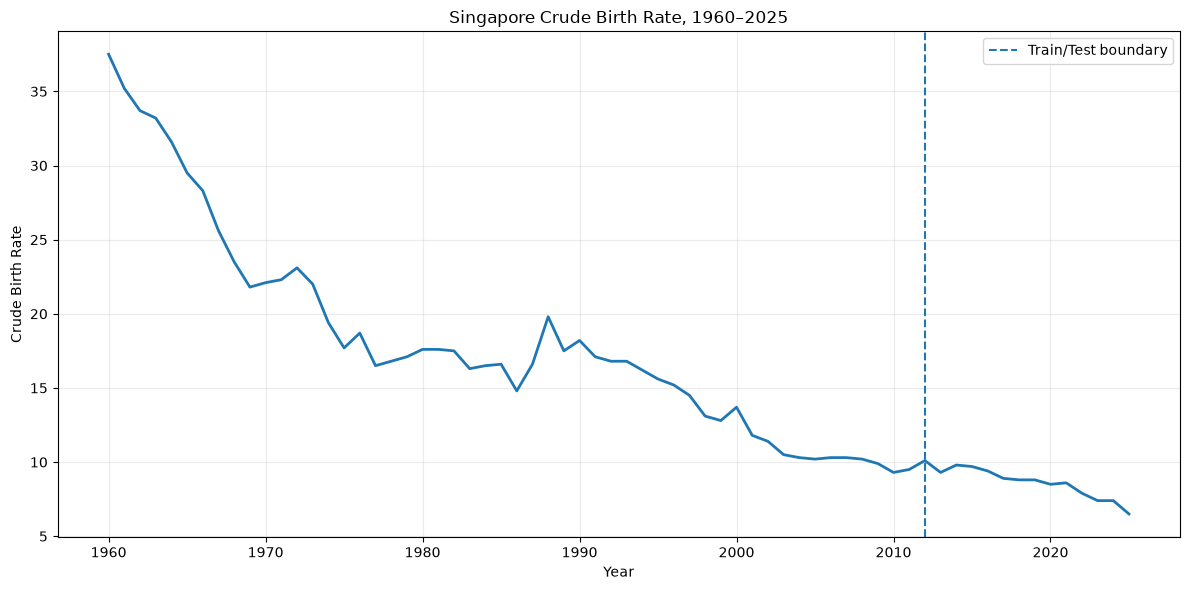

In [32]:
if "Crude_Birth_Rate" in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df["Year"], df["Crude_Birth_Rate"], linewidth=2)
    ax.axvline(2012, linestyle="--", linewidth=1.5,
               label="Train/Test boundary")
    ax.set_title("Singapore Crude Birth Rate, 1960–2025")
    ax.set_xlabel("Year")
    ax.set_ylabel("Crude Birth Rate")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "Figure_03_Crude_Birth_Rate_1960_2025.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Crude_Birth_Rate is not available.")

# Part D — Age-specific fertility

The dataset includes fertility rates for 15–19, 20–24, 25–29, 30–34, 35–39, 40–44 and 45–49 years.

The 45–49 series may have a shorter historical coverage.

These variables are primarily for demographic interpretation. We will not use age-specific fertility rates as the main independent predictors of TFR because they are closely related to how TFR is constructed.

Age-specific variables detected:
 - 15_19_Years
 - 20_24_Years
 - 25_29_Years
 - 30_34_Years
 - 35_39_Years
 - 40_44_Years
 - 45_49_Years


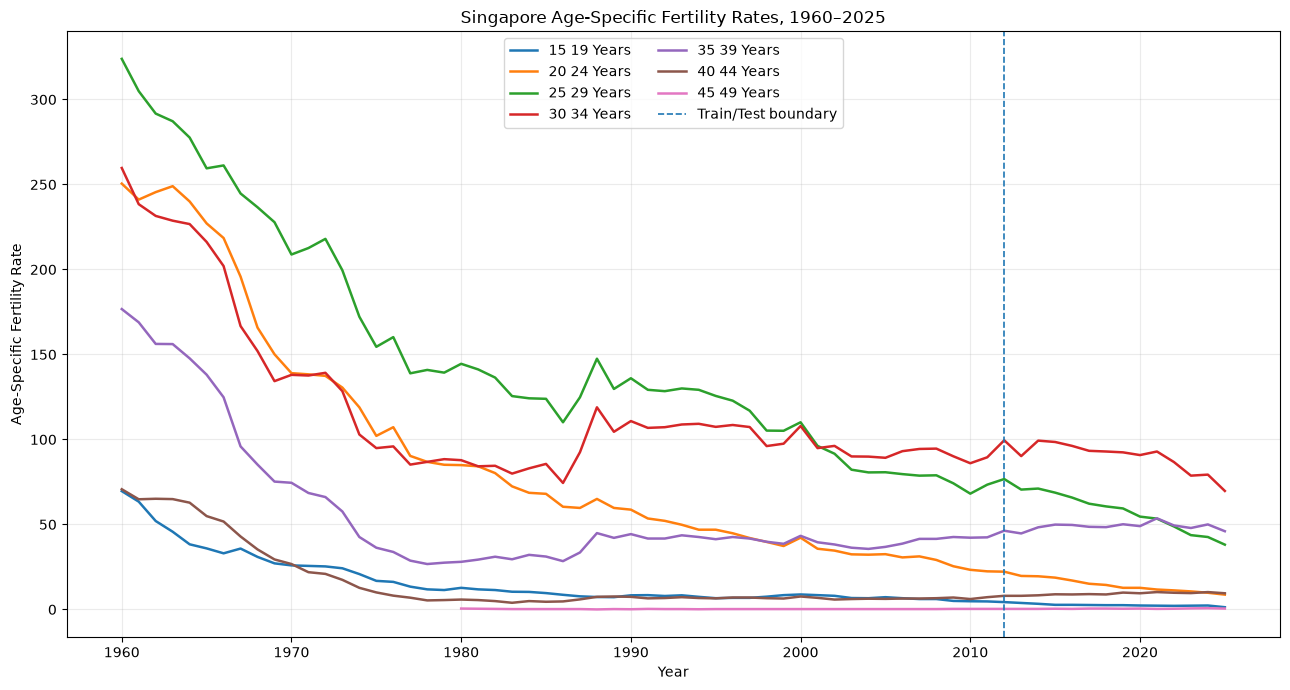

,Year,15_19_Years,20_24_Years,25_29_Years,30_34_Years,35_39_Years,40_44_Years,45_49_Years
0,1960,69.6000,250.5000,323.9000,259.7000,176.7000,70.7000,NaN
20,1980,12.7000,84.9000,144.5000,87.8000,28.0000,5.8000,0.5000
40,2000,8.8000,42.2000,110.1000,107.9000,43.3000,7.6000,0.2000
52,2012,4.3000,22.2000,76.7000,99.5000,46.3000,8.0000,0.3000
65,2025,1.3000,8.7000,38.1000,69.7000,46.0000,9.5000,0.5000


In [33]:
age_columns = [
    c for c in df.columns
    if re.search(r"\d+.*Years", c, flags=re.IGNORECASE)
]

print("Age-specific variables detected:")
for c in age_columns:
    print(" -", c)

if age_columns:
    fig, ax = plt.subplots(figsize=(13, 7))
    for col in age_columns:
        ax.plot(df["Year"], df[col], linewidth=1.8,
                label=col.replace("_", " "))
    ax.axvline(2012, linestyle="--", linewidth=1.2,
               label="Train/Test boundary")
    ax.set_title("Singapore Age-Specific Fertility Rates, 1960–2025")
    ax.set_xlabel("Year")
    ax.set_ylabel("Age-Specific Fertility Rate")
    ax.grid(alpha=0.25)
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "Figure_04_Age_Specific_Fertility.png"),
                dpi=300, bbox_inches="tight")
    plt.show()

age_years = [1960, 1980, 2000, 2012, 2025]
age_snapshot = df.loc[df["Year"].isin(age_years),
                      ["Year"] + age_columns]
display(age_snapshot)
age_snapshot.to_csv(os.path.join(TABLE_DIR, "eda_age_specific_selected_years.csv"),
                    index=False)

# Part E — Ethnic fertility

Ethnic fertility variables: ['Chinese', 'Malays', 'Indians']


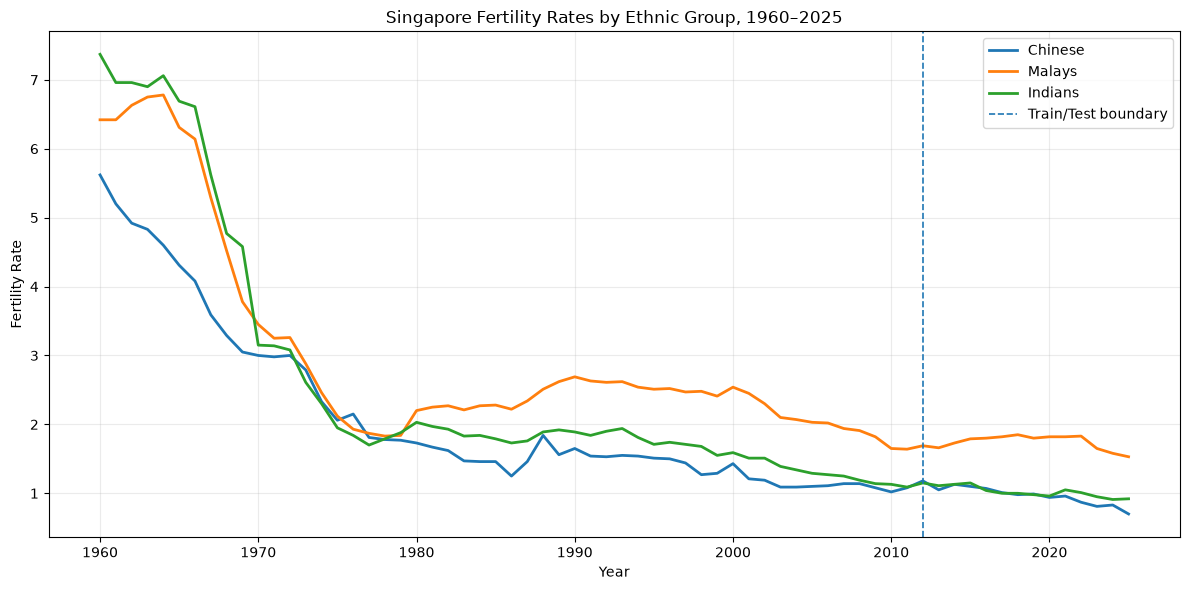

,Year,Chinese,Malays,Indians
0,1960,5.6200,6.4200,7.3700
20,1980,1.7300,2.2000,2.0300
40,2000,1.4300,2.5400,1.5900
52,2012,1.1800,1.6900,1.1500
65,2025,0.7000,1.5300,0.9200


In [34]:
ethnic_columns = [
    c for c in ["Chinese", "Malays", "Indians"] if c in df.columns
]

print("Ethnic fertility variables:", ethnic_columns)

if ethnic_columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    for col in ethnic_columns:
        ax.plot(df["Year"], df[col], linewidth=2, label=col)
    ax.axvline(2012, linestyle="--", linewidth=1.2,
               label="Train/Test boundary")
    ax.set_title("Singapore Fertility Rates by Ethnic Group, 1960–2025")
    ax.set_xlabel("Year")
    ax.set_ylabel("Fertility Rate")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "Figure_05_Ethnic_Fertility.png"),
                dpi=300, bbox_inches="tight")
    plt.show()

    ethnic_snapshot = df.loc[df["Year"].isin(age_years),
                             ["Year"] + ethnic_columns]
    display(ethnic_snapshot)
    ethnic_snapshot.to_csv(os.path.join(TABLE_DIR, "eda_ethnic_selected_years.csv"),
                           index=False)

# Part F — Total, resident and citizen live births

Birth-type variables: ['Total_Live_Births', 'Resident_Live_Births', 'Citizen_Live_Births']


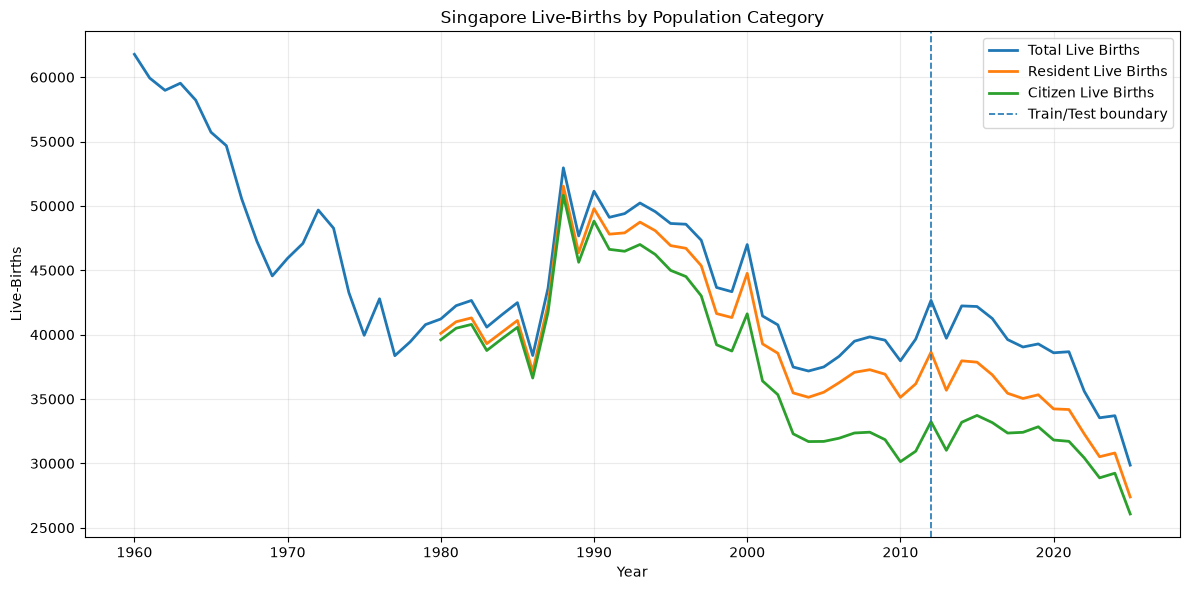

In [35]:
birth_type_columns = [
    c for c in [
        "Total_Live_Births",
        "Resident_Live_Births",
        "Citizen_Live_Births"
    ] if c in df.columns
]

print("Birth-type variables:", birth_type_columns)

if birth_type_columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    for col in birth_type_columns:
        ax.plot(df["Year"], df[col], linewidth=2,
                label=col.replace("_", " "))
    ax.axvline(2012, linestyle="--", linewidth=1.2,
               label="Train/Test boundary")
    ax.set_title("Singapore Live-Births by Population Category")
    ax.set_xlabel("Year")
    ax.set_ylabel("Live-Births")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "Figure_06_Births_by_Category.png"),
                dpi=300, bbox_inches="tight")
    plt.show()

# Part G — Gross and Net Reproduction Rates

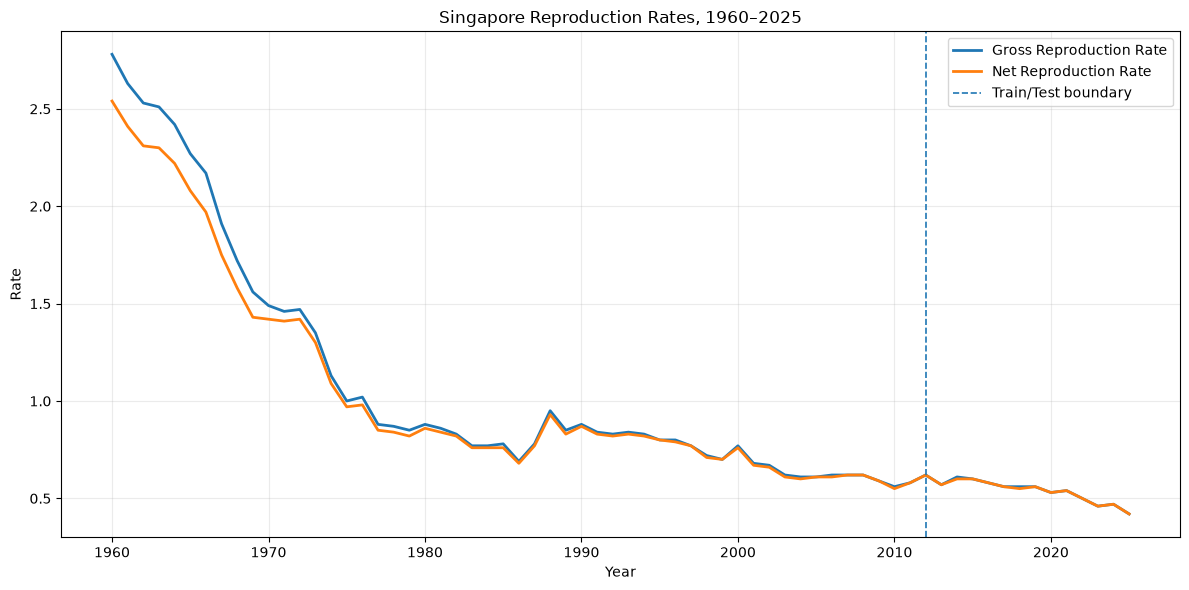

In [36]:
repro_columns = [
    c for c in ["Gross_Reproduction_Rate", "Net_Reproduction_Rate"]
    if c in df.columns
]

if repro_columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    for col in repro_columns:
        ax.plot(df["Year"], df[col], linewidth=2,
                label=col.replace("_", " "))
    ax.axvline(2012, linestyle="--", linewidth=1.2,
               label="Train/Test boundary")
    ax.set_title("Singapore Reproduction Rates, 1960–2025")
    ax.set_xlabel("Year")
    ax.set_ylabel("Rate")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "Figure_07_Reproduction_Rates.png"),
                dpi=300, bbox_inches="tight")
    plt.show()

# Part H — Smoothed birth trend

A five-year rolling mean is used only to make the long-term trend easier to see.

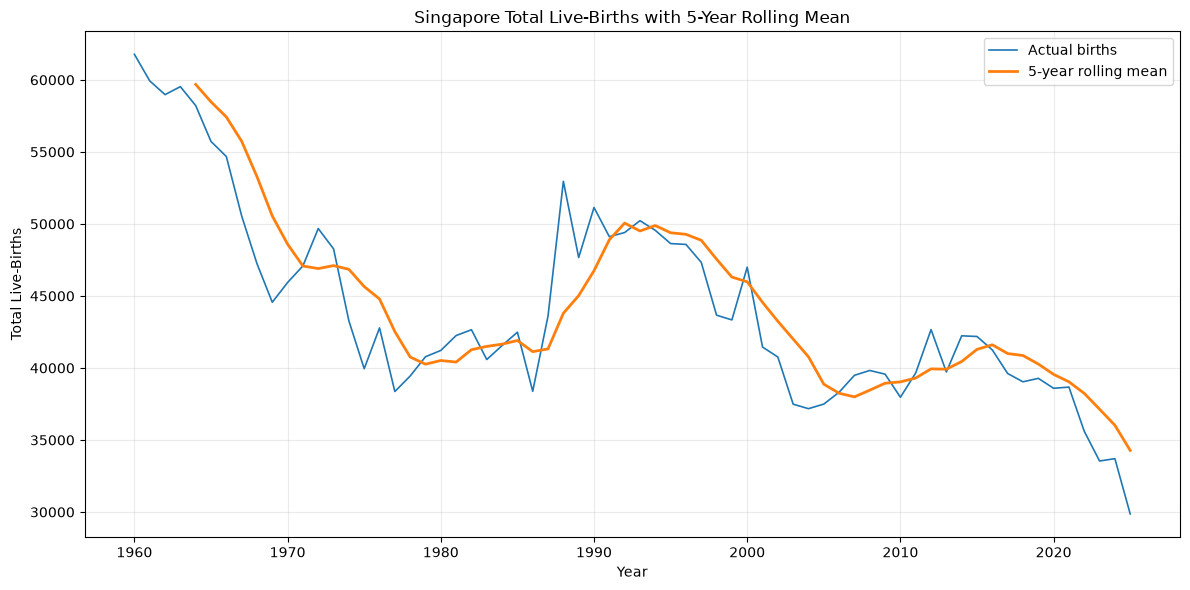

In [37]:
df["Births_Rolling_5Y"] = df["Total_Live_Births"].rolling(5).mean()
df["TFR_Rolling_5Y"] = df["Total_Fertility_Rate_TFR"].rolling(5).mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["Year"], df["Total_Live_Births"], linewidth=1.2,
        label="Actual births")
ax.plot(df["Year"], df["Births_Rolling_5Y"], linewidth=2,
        label="5-year rolling mean")
ax.set_title("Singapore Total Live-Births with 5-Year Rolling Mean")
ax.set_xlabel("Year")
ax.set_ylabel("Total Live-Births")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Figure_08_Births_5Y_Rolling_Mean.png"),
            dpi=300, bbox_inches="tight")
plt.show()

# Part I — Correlation analysis

Correlation is exploratory only.

We avoid treating age-specific fertility, GRR or NRR as independent causal predictors of TFR because they are closely related demographic measures.

In [38]:
corr_columns = [
    c for c in [
        "Total_Fertility_Rate",
        "Total_Live_Births",
        "Crude_Birth_Rate",
        "Gross_Reproduction_Rate",
        "Net_Reproduction_Rate",
        "Chinese", "Malays", "Indians"
    ] if c in df.columns
]

corr = df[corr_columns].corr()
display(corr)
corr.to_csv(os.path.join(TABLE_DIR, "eda_correlation_matrix.csv"))

,Total_Live_Births,Crude_Birth_Rate,Gross_Reproduction_Rate,Net_Reproduction_Rate,Chinese,Malays,Indians
Total_Live_Births,1.0000,0.8830,0.8459,0.8529,0.8391,0.8548,0.8229
Crude_Birth_Rate,0.8830,1.0000,0.9622,0.9665,0.9678,0.9140,0.9362
Gross_Reproduction_Rate,0.8459,0.9622,1.0000,0.9996,0.9977,0.9713,0.9878
Net_Reproduction_Rate,0.8529,0.9665,0.9996,1.0000,0.9983,0.9685,0.9844
Chinese,0.8391,0.9678,0.9977,0.9983,1.0000,0.9537,0.9769
Malays,0.8548,0.9140,0.9713,0.9685,0.9537,1.0000,0.9874
Indians,0.8229,0.9362,0.9878,0.9844,0.9769,0.9874,1.0000


# Part J — Training vs test period

In [39]:
period_summary = pd.DataFrame({
    "Period": ["Training (1960–2012)", "Test (2013–2025)"],
    "Start_Year": [1960, 2013],
    "End_Year": [2012, 2025],
    "Mean_Births": [
        df.loc[df["Year"].between(1960, 2012), "Total_Live_Births"].mean(),
        df.loc[df["Year"].between(2013, 2025), "Total_Live_Births"].mean()
    ],
    "Mean_TFR": [
        df.loc[df["Year"].between(1960, 2012), "Total_Fertility_Rate_TFR"].mean(),
        df.loc[df["Year"].between(2013, 2025), "Total_Fertility_Rate_TFR"].mean()
    ]
})
display(period_summary)
period_summary.to_csv(os.path.join(TABLE_DIR, "eda_train_test_summary.csv"),
                      index=False)

,Period,Start_Year,End_Year,Mean_Births,Mean_TFR
0,Training (1960–2012),1960,2012,"45,659.3208",2.2751
1,Test (2013–2025),2013,2025,"37,945.8462",1.1069


In [40]:
# Save the EDA-ready dataset with descriptive columns
EDA_PATH = "outputs/annual_birth_fertility_eda.csv"
os.makedirs("outputs", exist_ok=True)
df.to_csv(EDA_PATH, index=False)

print("EDA dataset saved to:", EDA_PATH)
print("Figures saved to:", FIG_DIR)
print("Tables saved to:", TABLE_DIR)

EDA dataset saved to: outputs/annual_birth_fertility_eda.csv
Figures saved to: figures
Tables saved to: tables
